<a href="https://colab.research.google.com/github/XuningZhuang/MSSP6070/blob/main/Assignments/Assignment1_Xuning_Zhuang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_academic_performance.xlsx to data_academic_performance.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('data_academic_performance.xlsx', sheet_name='SABER11_SABERPRO')
df.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [3]:
#basic data quality checks
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

missing_values = df.isna().sum()
print("\nMissing values:")
print(missing_values[missing_values > 0])

Rows: 12411
Columns: 45
Duplicate rows: 0

Missing values:
Unnamed: 9    12411
dtype: int64


In [4]:
categorical_cols = [
    'GENDER', 'EDU_FATHER', 'EDU_MOTHER',
    'OCC_FATHER', 'OCC_MOTHER', 'STRATUM',
    'SISBEN', 'PEOPLE_HOUSE', 'REVENUE', 'JOB',
    'SCHOOL_NAT', 'SCHOOL_TYPE',
    'UNIVERSITY', 'ACADEMIC_PROGRAM']

for column in categorical_cols:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.strip("'")
        .str.strip('"')
        .str.strip()
    )


In [5]:
#overall performance
global_score_summary = df['G_SC'].describe()

print(global_score_summary)

count    12411.000000
mean       162.710499
std         23.112479
min         37.000000
25%        147.000000
50%        163.000000
75%        179.000000
max        247.000000
Name: G_SC, dtype: float64


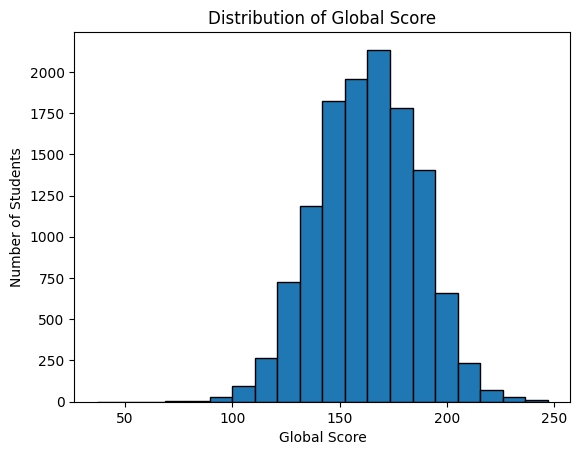

In [6]:
plt.hist(df['G_SC'], bins=20, edgecolor='black')

plt.xlabel('Global Score')
plt.ylabel('Number of Students')
plt.title('Distribution of Global Score')

plt.show()

In [7]:
#mean scores for teo period seperately
s11_cols = ['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11']
pro_cols = ['QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO']

s11_means = df[s11_cols].mean()
pro_means = df[pro_cols].mean()

print("Saber 11 mean scores:")
print(s11_means.sort_values())

print("\nSaber Pro mean scores:")
print(pro_means.sort_values())

print("\nFEP_PRO mean:")
print(df['FEP_PRO'].mean())

Saber 11 mean scores:
CC_S11     60.705181
CR_S11     60.778422
ENG_S11    61.801064
BIO_S11    63.950528
MAT_S11    64.320764
dtype: float64

Saber Pro mean scores:
WC_PRO     53.703408
CC_PRO     59.186770
CR_PRO     62.199339
ENG_PRO    67.498348
QR_PRO     77.417291
dtype: float64

FEP_PRO mean:
145.47659334461366


In [8]:
#mean score for each Saber 11 assessment domain
s11_means = df[s11_cols].mean()
print("mean of each subject in s11:",s11_means.sort_values())

#mean score for each Saber Pro assessment domain

pro_means = df[pro_cols].mean()
print("mean of each subject in pro:", pro_means.sort_values())

mean of each subject in s11: CC_S11     60.705181
CR_S11     60.778422
ENG_S11    61.801064
BIO_S11    63.950528
MAT_S11    64.320764
dtype: float64
mean of each subject in pro: WC_PRO     53.703408
CC_PRO     59.186770
CR_PRO     62.199339
ENG_PRO    67.498348
QR_PRO     77.417291
dtype: float64


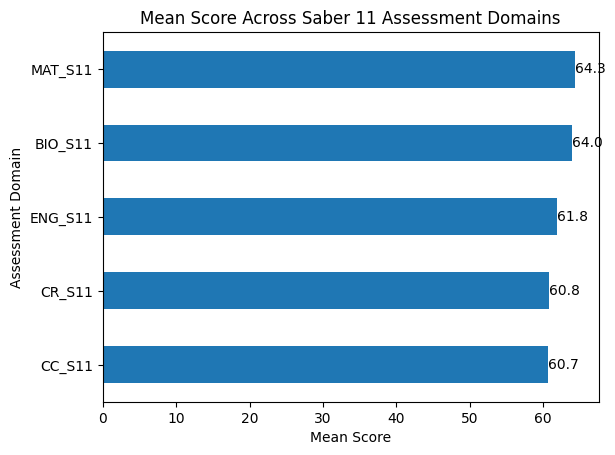

In [9]:
#mean score by Saber 11 assessment domain
ax = s11_means.sort_values().plot(kind='barh')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('Mean Score')
plt.ylabel('Assessment Domain')
plt.title('Mean Score Across Saber 11 Assessment Domains')

plt.show()

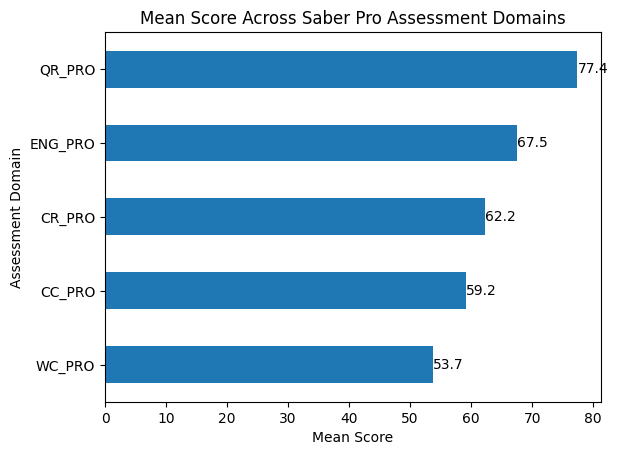

In [10]:
#mean score by Saber pro assessment domain
pro_score_cols = [
    'QR_PRO',
    'CR_PRO',
    'CC_PRO',
    'ENG_PRO',
    'WC_PRO']

pro_score_means = df[pro_score_cols].mean()

ax = pro_score_means.sort_values().plot(kind='barh')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('Mean Score')
plt.ylabel('Assessment Domain')
plt.title('Mean Score Across Saber Pro Assessment Domains')

plt.show()

In [11]:
highest_s11_mean = s11_means.max()
lowest_s11_mean = s11_means.min()

print(highest_s11_mean - lowest_s11_mean)

3.615582950608335


In [12]:
numeric_cols = [
    'MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11',
    'QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO',
    'WC_PRO', 'FEP_PRO', 'G_SC', 'PERCENTILE',
    '2ND_DECILE', 'QUARTILE', 'SEL', 'SEL_IHE']

overall_summary = df[numeric_cols].describe().T

print(overall_summary[['count', 'mean', 'std', 'min', '50%', 'max']])


              count        mean        std   min    50%    max
MAT_S11     12411.0   64.320764  11.873650  26.0   64.0  100.0
CR_S11      12411.0   60.778422  10.025876  24.0   61.0  100.0
CC_S11      12411.0   60.705181  10.120524   0.0   60.0  100.0
BIO_S11     12411.0   63.950528  11.156869  11.0   64.0  100.0
ENG_S11     12411.0   61.801064  14.297777  26.0   59.0  100.0
QR_PRO      12411.0   77.417291  22.673444   1.0   85.0  100.0
CR_PRO      12411.0   62.199339  27.666558   1.0   67.0  100.0
CC_PRO      12411.0   59.186770  28.991840   1.0   65.0  100.0
ENG_PRO     12411.0   67.498348  25.495096   1.0   74.0  100.0
WC_PRO      12411.0   53.703408  30.001734   0.0   56.0  100.0
FEP_PRO     12411.0  145.476593  40.126386   1.0  153.0  300.0
G_SC        12411.0  162.710499  23.112479  37.0  163.0  247.0
PERCENTILE  12411.0   68.446459  25.867550   1.0   75.0  100.0
2ND_DECILE  12411.0    3.885747   1.248431   1.0    4.0    5.0
QUARTILE    12411.0    3.188865   0.979043   1.0    4.0

In [13]:
#for parental father education
father_stats = df.groupby('EDU_FATHER')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print(father_stats)
print(father_stats.sort_values('mean', ascending = False))

                                       count        mean  median        std
EDU_FATHER                                                                 
0                                        391  155.076726   155.0  20.057207
Complete Secundary                      2843  158.785790   159.0  22.114288
Complete primary                         824  155.195388   155.0  22.410767
Complete professional education         3016  167.765915   169.0  23.030089
Complete technique or technology        1194  164.033501   164.0  22.165359
Incomplete Professional Education        425  166.917647   168.0  22.685198
Incomplete Secundary                    1091  156.535289   157.0  21.736989
Incomplete primary                       735  155.729252   156.0  20.942412
Incomplete technical or technological    277  162.101083   162.0  21.881198
Ninguno                                  123  156.634146   159.0  23.188560
Not sure                                 407  160.294840   159.0  22.939555
Postgraduate

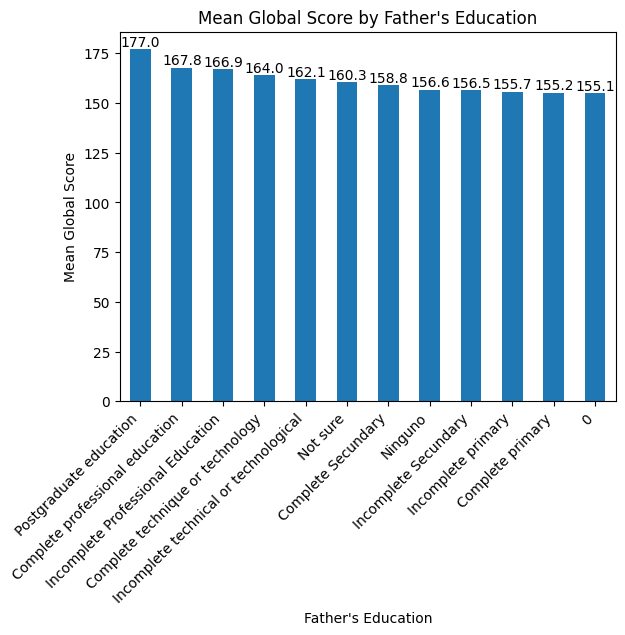

In [14]:
#mean Global Score by Father's Education
father_education_means = (df.groupby('EDU_FATHER')['G_SC'].mean().sort_values(ascending=False))

ax = father_education_means.plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel("Father's Education")
plt.ylabel("Mean Global Score")
plt.title("Mean Global Score by Father's Education")
plt.xticks(rotation=45, ha='right')
plt.show()


In [15]:
#for parental mother education
mother_stats = df.groupby('EDU_MOTHER')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print(mother_stats)
print(mother_stats.sort_values('mean', ascending = False))

                                       count        mean  median        std
EDU_MOTHER                                                                 
0                                        388  154.930412   155.0  19.954154
Complete Secundary                      3106  158.470702   159.0  21.949597
Complete primary                         713  155.336606   155.0  22.012293
Complete professional education         3059  168.845374   170.0  22.978321
Complete technique or technology        1495  163.242140   163.0  21.943495
Incomplete Professional Education        502  166.685259   168.0  22.931830
Incomplete Secundary                    1056  155.672348   156.0  21.928635
Incomplete primary                       541  154.853974   155.0  21.636024
Incomplete technical or technological    341  161.879765   164.0  20.744388
Ninguno                                   34  149.705882   152.5  27.930139
Not sure                                 179  159.407821   159.0  25.469659
Postgraduate

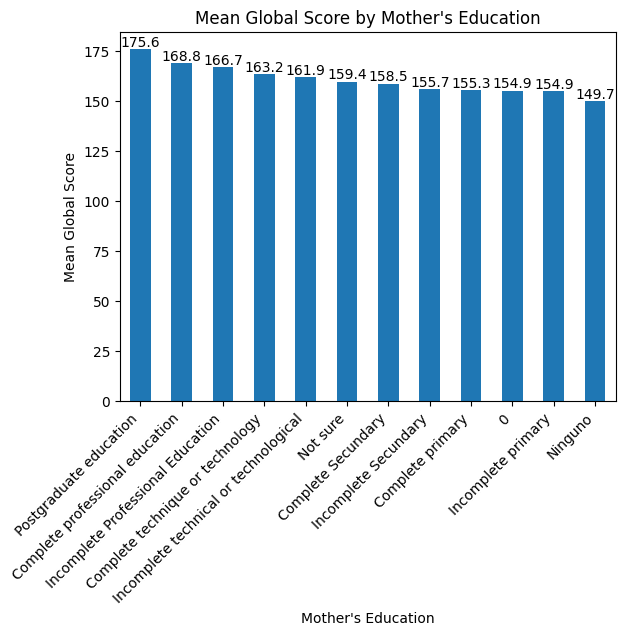

In [16]:
#mean Global Score by Mother's Education
mother_education_means = (df.groupby('EDU_MOTHER')['G_SC'].mean().sort_values(ascending=False))

ax = mother_education_means.plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel("Mother's Education")
plt.ylabel("Mean Global Score")
plt.title("Mean Global Score by Mother's Education")
plt.xticks(rotation=45, ha='right')
plt.show()

In [17]:
father_edu_diff = (father_stats.loc['Postgraduate education', 'mean'] - father_stats.loc['Ninguno', 'mean'])
mother_edu_diff = (mother_stats.loc['Postgraduate education', 'mean'] - mother_stats.loc['Ninguno', 'mean'])

print(father_edu_diff)
print(mother_edu_diff)

20.35110711475778
25.931028379255395


The mean globle score for students whose father have postgraduate education is 176.985253. But the globle score for students whose father who don't have education（Ninguno） is only 156.634146. So that the difference is 20.35110711475778.
Similarly, the mean globle score for students whose mother have postgraduate education is 175.636911. But the globle score for students whose mother who don't have education（Ninguno） is only 149.705882. So that the difference is 25.931028379255395.

Students whose parents had postgraduate education had a higher average Global Score than students whose parents don't have education.The big gap between the G_SC of Postgraduate and the G_SC of Ninguno shows the effect is relatively significant. Also, from the chart, we can notice that higher parental educational-attainment categories generally have higher observed Global Score averages.

In [18]:
#by SEL
sel_stats = df.groupby('SEL')['G_SC'].mean()

print(sel_stats)

SEL
1    155.472404
2    158.542598
3    162.303152
4    171.583416
Name: G_SC, dtype: float64


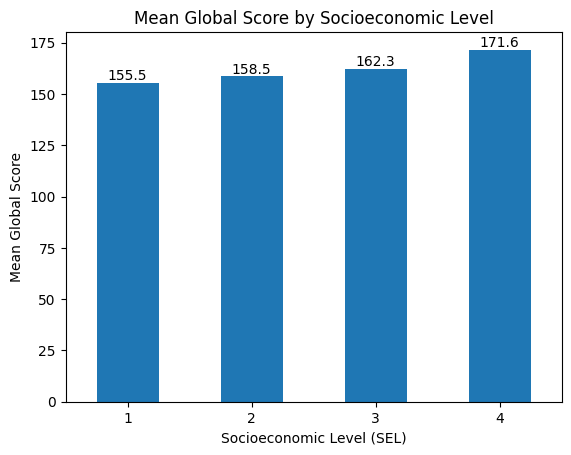

In [19]:
ax = sel_stats.plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('Socioeconomic Level (SEL)')
plt.ylabel('Mean Global Score')
plt.title('Mean Global Score by Socioeconomic Level')
plt.xticks(rotation=0)
plt.show()

In [20]:
#by stratum
stratum_stats = df.groupby('STRATUM')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print(stratum_stats.sort_values('mean', ascending=False))

           count        mean  median        std
STRATUM                                        
Stratum 6    403  181.511166   184.0  21.879401
Stratum 5    633  177.387046   179.0  21.543236
Stratum 4   1578  172.002535   174.0  21.469094
Stratum 3   4045  163.815328   164.0  21.693970
Stratum 2   4029  158.199305   158.0  22.278029
0             14  154.000000   152.5  21.321712
Stratum 1   1709  152.352838   152.0  21.937401


So that the stratum 6 has highest observed mean Global Score

In [21]:
highest_stratum_mean = stratum_stats['mean'].max()
lowest_stratum_mean = stratum_stats['mean'].min()

print(highest_stratum_mean - lowest_stratum_mean)


29.15832833619126


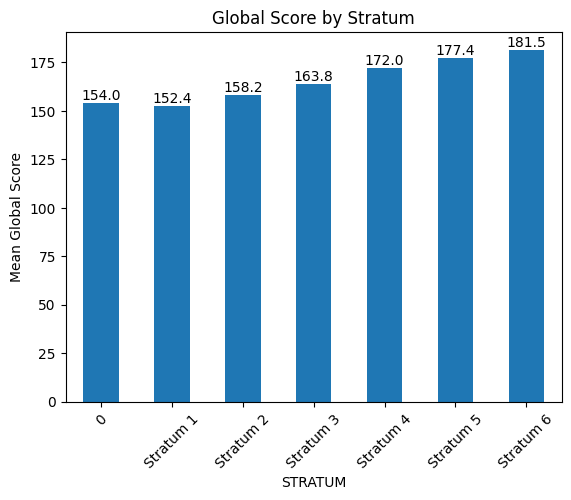

In [22]:
ax = stratum_stats.sort_index()['mean'].plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.ylabel('Mean Global Score')
plt.title('Global Score by Stratum')
plt.xticks(rotation=45)
plt.show()


The observed mean Global Score varies across strata. The highest mean is 181.51 and the lowest is 152.35, The difference between the highest and lowest observed stratum means is 29.15832833619126 points.
The results show differences between strata, but they do not establish that stratum itself causes the difference.

In [23]:
#by household revenue
revenue_stats = df.groupby('REVENUE')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print(revenue_stats.sort_values('mean', ascending=False))

                                 count        mean  median        std
REVENUE                                                              
10 or more LMMW                    718  183.672702   185.0  20.722113
Between 7 and less than 10 LMMW    509  176.176817   178.0  19.964343
Between 5 and less than 7 LMMW     973  170.860226   172.0  21.786822
0                                  279  169.716846   172.0  22.637003
Between 3 and less than 5 LMMW    2239  165.336311   167.0  22.075666
Between 2 and less than 3 LMMW    2783  160.942867   162.0  21.633473
Between 1 and less than 2 LMMW    3873  156.770462   157.0  22.045776
less than 1 LMMW                  1037  153.314368   153.0  22.014683


In [24]:
revenue_order = [
    '0',
    'less than 1 LMMW',
    'Between 1 and less than 2 LMMW',
    'Between 2 and less than 3 LMMW',
    'Between 3 and less than 5 LMMW',
    'Between 5 and less than 7 LMMW',
    'Between 7 and less than 10 LMMW',
    '10 or more LMMW']

revenue_stats_ordered = revenue_stats.reindex(revenue_order)

print(revenue_stats_ordered)

                                 count        mean  median        std
REVENUE                                                              
0                                  279  169.716846   172.0  22.637003
less than 1 LMMW                  1037  153.314368   153.0  22.014683
Between 1 and less than 2 LMMW    3873  156.770462   157.0  22.045776
Between 2 and less than 3 LMMW    2783  160.942867   162.0  21.633473
Between 3 and less than 5 LMMW    2239  165.336311   167.0  22.075666
Between 5 and less than 7 LMMW     973  170.860226   172.0  21.786822
Between 7 and less than 10 LMMW    509  176.176817   178.0  19.964343
10 or more LMMW                    718  183.672702   185.0  20.722113


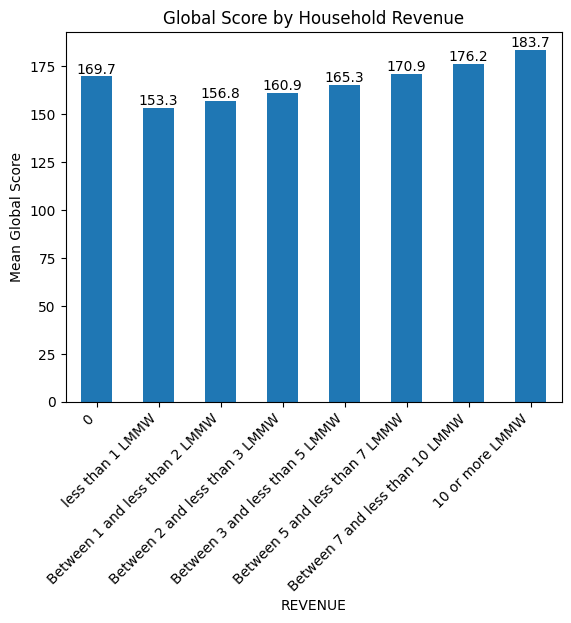

In [25]:
ax = revenue_stats_ordered['mean'].plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.ylabel('Mean Global Score')
plt.title('Global Score by Household Revenue')
plt.xticks(rotation=45, ha='right')
plt.show()


In [26]:
#by SISBEN
sisben_stats = df.groupby('SISBEN')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print(sisben_stats.sort_values('mean', ascending=False))


                                           count        mean  median  \
SISBEN                                                                 
It is not classified by the SISBEN          7534  167.469074   169.0   
Esta clasificada en otro Level del SISBEN     96  166.052083   167.0   
Level 3                                      583  160.991424   161.0   
0                                             21  158.619048   156.0   
Level 2                                     2120  155.893396   156.0   
Level 1                                     2057  152.680603   152.0   

                                                 std  
SISBEN                                                
It is not classified by the SISBEN         22.478021  
Esta clasificada en otro Level del SISBEN  22.511457  
Level 3                                    21.640175  
0                                          20.086006  
Level 2                                    22.268725  
Level 1                               

In [27]:
sisben_order = [
    'Level 1',
    'Level 2',
    'Level 3',
    'It is not classified by the SISBEN',
    'Esta clasificada en otro Level del SISBEN']

sisben_stats_ordered = sisben_stats.reindex(sisben_order)

print(sisben_stats_ordered)

                                           count        mean  median  \
SISBEN                                                                 
Level 1                                     2057  152.680603   152.0   
Level 2                                     2120  155.893396   156.0   
Level 3                                      583  160.991424   161.0   
It is not classified by the SISBEN          7534  167.469074   169.0   
Esta clasificada en otro Level del SISBEN     96  166.052083   167.0   

                                                 std  
SISBEN                                                
Level 1                                    21.657454  
Level 2                                    22.268725  
Level 3                                    21.640175  
It is not classified by the SISBEN         22.478021  
Esta clasificada en otro Level del SISBEN  22.511457  


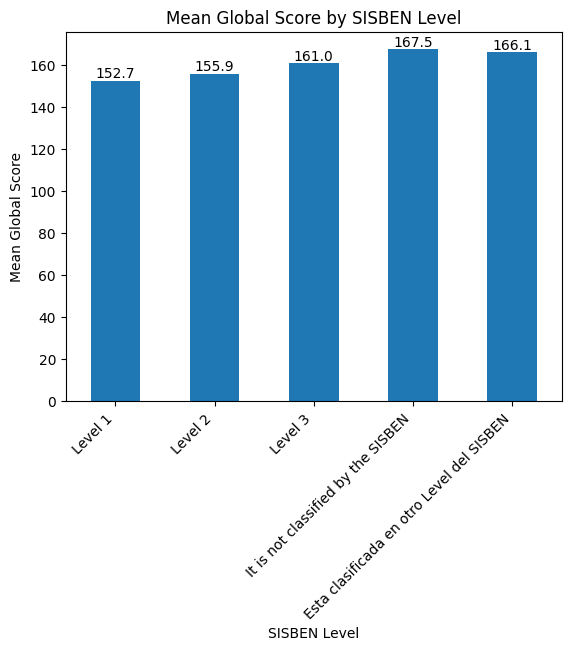

In [28]:
ax = sisben_stats_ordered['mean'].plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('SISBEN Level')
plt.ylabel('Mean Global Score')
plt.title('Mean Global Score by SISBEN Level')
plt.xticks(rotation=45, ha='right')
plt.show()

In [29]:
#by gender
gender_stats = df.groupby('GENDER')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print(gender_stats)


        count        mean  median        std
GENDER                                      
F        5043  161.278207   162.0  22.332939
M        7368  163.690825   164.0  23.582616


In [30]:
gender_difference = abs(gender_stats.loc['M', 'mean'] - gender_stats.loc['F', 'mean'])

print(gender_difference)


2.4126177737903447


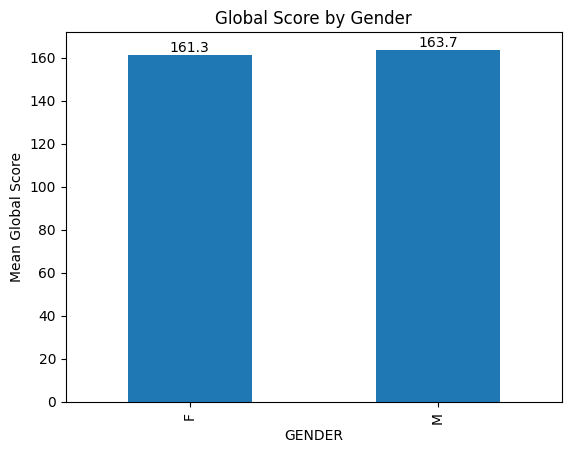

In [31]:
ax = gender_stats['mean'].plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.ylabel('Mean Global Score')
plt.title('Global Score by Gender')
plt.show()


The mean Global Score is 161.278207 for F and 163.690825 for M. The absolute difference between the two means is around 2.4126 points.
This is only a descriptive comparison of the students for each gender in the dataset and does not establish a causal gender effect.

In [32]:
#by school nature
school_nature_stats = df.groupby('SCHOOL_NAT')['G_SC'].agg(['count', 'mean', 'median', 'std'])

print("School nature:", school_nature_stats.sort_values('mean', ascending=False))


school_type_stats = df.groupby('SCHOOL_TYPE')['G_SC'].agg(['count', 'mean', 'median', 'std'])
print("School type:", school_type_stats.sort_values('mean', ascending=False))


School nature:             count        mean  median        std
SCHOOL_NAT                                      
PRIVATE      6565  168.215842   170.0  22.823659
PUBLIC       5846  156.528053   157.0  21.838175
School type:                     count        mean  median        std
SCHOOL_TYPE                                             
ACADEMIC             7834  165.851800   167.0  23.254263
TECHNICAL/ACADEMIC   3513  157.485056   157.0  21.844941
TECHNICAL            1059  156.864023   157.0  21.832634
Not apply               5  150.600000   159.0  27.736258


In [33]:
school_nature_diff = (school_nature_stats.loc['PRIVATE','mean'] - school_nature_stats.loc['PUBLIC','mean'])

print(school_nature_diff)

11.687788214332897


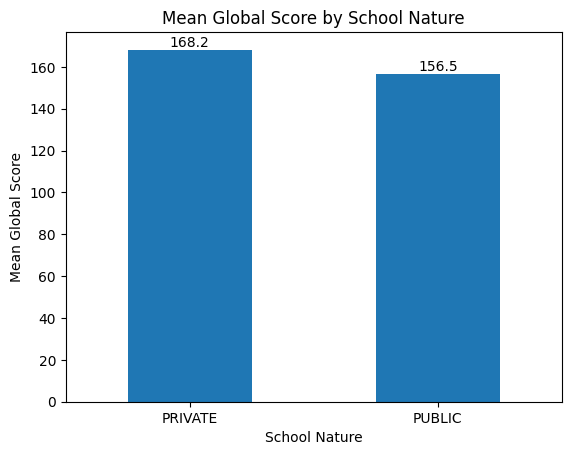

In [34]:
ax = school_nature_stats['mean'].plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('School Nature')
plt.ylabel('Mean Global Score')
plt.title('Mean Global Score by School Nature')
plt.xticks(rotation=0)
plt.show()

In [35]:
#by school type
school_type_means = df.groupby('SCHOOL_TYPE')['G_SC'].mean()

print(school_type_means)

SCHOOL_TYPE
ACADEMIC              165.851800
Not apply             150.600000
TECHNICAL             156.864023
TECHNICAL/ACADEMIC    157.485056
Name: G_SC, dtype: float64


In [36]:
highest_schooltype_mean = school_type_means.max()
lowest_schooltype_mean = school_type_means.min()

print(highest_schooltype_mean - lowest_schooltype_mean)

15.251799846821541


In [37]:
school_type_order = [
    'TECHNICAL',
    'TECHNICAL/ACADEMIC',
    'ACADEMIC',
    'Not apply']

school_type_stats_ordered = school_type_stats.reindex(school_type_order)

print(school_type_stats_ordered)

                    count        mean  median        std
SCHOOL_TYPE                                             
TECHNICAL            1059  156.864023   157.0  21.832634
TECHNICAL/ACADEMIC   3513  157.485056   157.0  21.844941
ACADEMIC             7834  165.851800   167.0  23.254263
Not apply               5  150.600000   159.0  27.736258


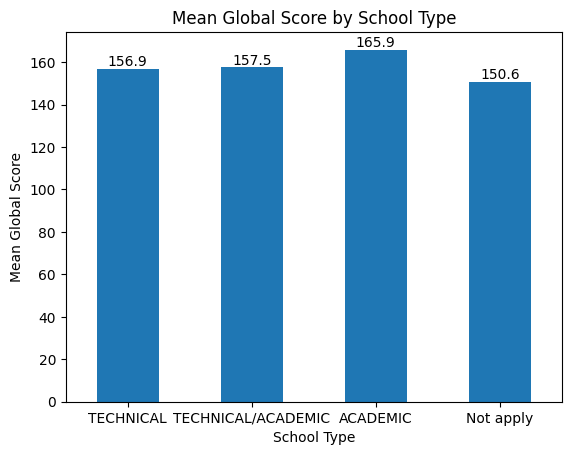

In [38]:
ax = school_type_stats_ordered['mean'].plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('School Type')
plt.ylabel('Mean Global Score')
plt.title('Mean Global Score by School Type')
plt.xticks(rotation=0)
plt.show()

In [39]:
#academic programs with at least 100 students
program_stats = df.groupby('ACADEMIC_PROGRAM')['G_SC'].agg(['count', 'mean', 'median', 'std'])
program_stats_n100 = program_stats[program_stats['count'] >= 100]

print(program_stats_n100.sort_values('mean', ascending=False))


                        count        mean  median        std
ACADEMIC_PROGRAM                                            
CHEMICAL ENGINEERING     1000  176.697000   177.0  18.690707
ELECTRIC ENGINEERING      278  173.989209   174.5  19.354285
ELECTRONIC ENGINEERING    849  166.872792   167.0  22.204832
MECHANICAL ENGINEERING   1135  166.051982   166.0  23.262628
CIVIL ENGINEERING        3320  161.110542   161.0  22.825922
INDUSTRIAL ENGINEERING   5318  159.042497   159.0  23.159611


In [40]:
program_difference = (program_stats_n100['mean'].max() - program_stats_n100['mean'].min())

print(program_difference)


17.654502820609252


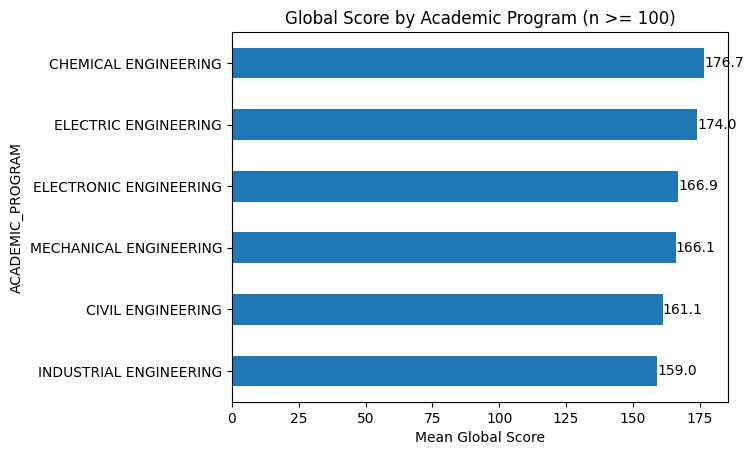

In [41]:
ax = program_stats_n100.sort_values('mean')['mean'].plot(kind='barh')

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.xlabel('Mean Global Score')
plt.title('Global Score by Academic Program (n >= 100)')
plt.show()

In [42]:
#correlation
assessment_cols = ['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11', 'QR_PRO', 'CR_PRO', 'CC_PRO',
                   'ENG_PRO', 'WC_PRO', 'FEP_PRO']

correlations = df[assessment_cols + ['G_SC']].corr()['G_SC']
correlations = correlations.sort_values(ascending=False)

print(correlations)


G_SC       1.000000
CR_PRO     0.786409
CC_PRO     0.757822
ENG_PRO    0.724643
QR_PRO     0.699914
BIO_S11    0.666635
ENG_S11    0.662169
CR_S11     0.653572
MAT_S11    0.643838
CC_S11     0.634900
WC_PRO     0.554962
FEP_PRO    0.373643
Name: G_SC, dtype: float64


In [43]:
s11_cols = ['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11']
pro_cols = ['QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO']

df['S11_AVG'] = df[s11_cols].mean(axis=1)
df['PRO_AVG'] = df[pro_cols].mean(axis=1)

df['PRO_S11_diff'] = df['PRO_AVG'] - df['S11_AVG']

print(df[['S11_AVG', 'PRO_AVG', 'PRO_S11_diff']].describe())


            S11_AVG       PRO_AVG  PRO_S11_diff
count  12411.000000  12411.000000  12411.000000
mean      62.311192     77.580292     15.269100
std        9.642924     19.730942     14.094823
min       35.800000     11.333333    -46.300000
25%       55.200000     63.500000      5.633333
50%       61.800000     78.833333     16.500000
75%       69.000000     93.000000     25.833333
max       95.600000    128.500000     75.833333
